In [2]:
import polars as pl

churn = pl.read_csv('Churn_Modelling.csv')

In [3]:
churn

RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
i64,i64,str,i64,str,str,f64,i64,f64,i64,i64,i64,f64,i64
1,15634602,"""Hargrave""",619,"""France""","""Female""",42.0,2,0.0,1,1,1,101348.88,1
2,15647311,"""Hill""",608,"""Spain""","""Female""",41.0,1,83807.86,1,0,1,112542.58,0
3,15619304,"""Onio""",502,"""France""","""Female""",42.0,8,159660.8,3,1,0,113931.57,1
4,15701354,"""Boni""",699,"""France""","""Female""",39.0,1,0.0,2,0,0,93826.63,0
5,15737888,"""Mitchell""",850,"""Spain""","""Female""",43.0,2,125510.82,1,null,1,79084.1,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…
9998,15584532,"""Liu""",709,"""France""","""Female""",36.0,7,0.0,1,0,1,42085.58,1
9999,15682355,"""Sabbatini""",772,"""Germany""","""Male""",42.0,3,75075.31,2,1,0,92888.52,1
9999,15682355,"""Sabbatini""",772,"""Germany""","""Male""",42.0,3,75075.31,2,1,0,92888.52,1


In [4]:
churn.select(
        pl.selectors.numeric()
).describe()

statistic,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",10002.0,10002.0,10002.0,10001.0,10002.0,10002.0,10002.0,10001.0,10001.0,10002.0,10002.0
"""null_count""",0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
"""mean""",5001.4996,1.5691e7,650.555089,38.922311,5.012498,76491.112875,1.530194,0.705529,0.514949,100083.331145,0.203759
"""std""",2887.472338,71931.769345,96.661615,10.4872,2.891973,62393.474144,0.581639,0.455827,0.499801,57508.117802,0.402812
"""min""",1.0,1.5565701e7,350.0,18.0,0.0,0.0,1.0,0.0,0.0,11.58,0.0
"""25%""",2501.0,1.5628523e7,584.0,32.0,3.0,0.0,1.0,0.0,0.0,50974.57,0.0
"""50%""",5002.0,1.5690733e7,652.0,37.0,5.0,97208.46,1.0,1.0,1.0,100187.43,0.0
"""75%""",7502.0,1.5753229e7,718.0,44.0,7.0,127649.64,2.0,1.0,1.0,149384.43,0.0
"""max""",10000.0,1.581569e7,850.0,92.0,10.0,250898.09,4.0,1.0,1.0,199992.48,1.0


In [51]:
df_no_nan = df.drop_nulls()

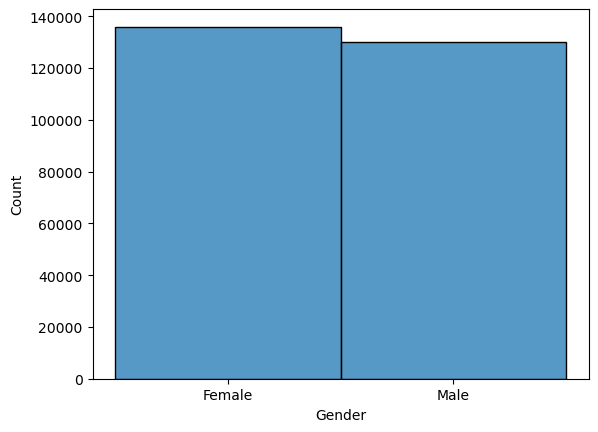

In [52]:
import seaborn_polars as snl

snl.histplot(
    df_no_nan,
    x="Gender"
)

In [36]:
male_count = train[train.Gender == "Male"].shape[0]
female_count = train[train.Gender == "Female"].shape[0]
print(f'Male :{male_count}')
print(f'Female: {female_count}')

Male :250252
Female: 190580


In [37]:
unequal_gender = male_count - female_count
drop_unequal_index = train[train["Gender"] == "Male"].iloc[:unequal_gender].index
train_cp = train.drop(drop_unequal_index, axis=0)

<Axes: xlabel='Gender', ylabel='Count'>

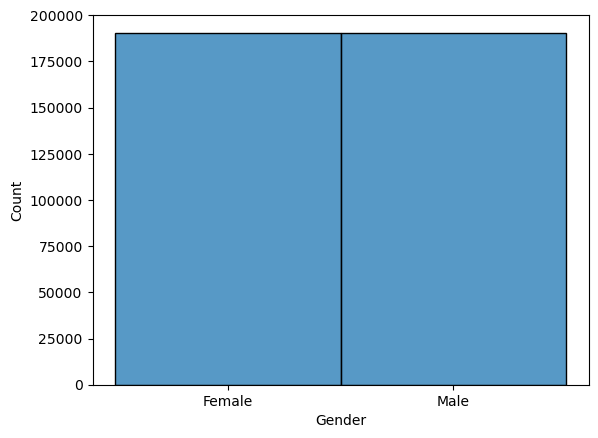

In [38]:
sns.histplot(
    train_cp,
    x="Gender"
)

In [127]:
from sklearn.preprocessing import OrdinalEncoder, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(train_cp.iloc[:, :-1], train_cp.iloc[:, -1], random_state=42)

scaler = RobustScaler()
encoder = OrdinalEncoder()
rfc = RandomForestClassifier()

numerical_cols = X_train.select_dtypes(include='number').columns
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
categorical_cols = X_train.select_dtypes(include='object').columns
X_train[categorical_cols] = encoder.fit_transform(X_train[categorical_cols])

scores = cross_val_score(rfc, X_train, y_train.values, n_jobs=4)
print("Cross-validation scores: {}".format(scores.mean()))

Cross-validation scores: 0.999345856508203
